In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import sys, math
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Ajout du chemin du dossier src au sys.path
src_path = Path("../src").resolve()
if src_path not in sys.path:
    sys.path.append(str(src_path))

# Importation des modules nécessaires
from analysis_utils import top_correlated_features, plot_numeric_histograms, plot_missing_bar 
from cleaning_utils import get_missing_summary,  get_special_columns

## Liens pour télécharger le jeu de donnéee et la description

Téléchargez le datast et metteez le dans le dossier data/raw

- [Dataset](https://drive.google.com/file/d/1C-tYJcgJDx5AuF7_oz7U4bbY0PERiFLo/view?usp=sharing)
- [Description](https://drive.google.com/file/d/1VSRPKK6ys0Kn3gSYDHgrQogdBAHXcEKg/view?usp=sharing)

## Définitions des Chemins

In [12]:
ROOT = (Path.cwd().parent).resolve()
# Ajouter le dossier 'src' au chemin de recherche des modules
src_path = ROOT / "src"
sys.path.append(str(src_path))

# DATA = (Path(__file__).parent / "df"/ "water_portability.csv").resolve()
# Path.cwd() cible le dossier racine où tourne ton notebook
DATA = (Path.cwd().parent / "data" / "raw"/ "water_potability.csv").resolve()

if DATA.exists():
    print(f"✅ Fichier trouvé ! Chemin : {DATA}")
else:
    print(f"❌ Erreur : Le fichier n'existe pas à l'emplacement {DATA}")

✅ Fichier trouvé ! Chemin : C:\Users\ayoub\Documents\waterflow\data\raw\water_potability.csv


In [13]:
df = pd.read_csv(DATA)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [20]:
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [21]:
df.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


## Définition de la target et de features

In [22]:
TARGET = df["Potability"]
FEATURES = [col for col in df.columns if col != TARGET.name]

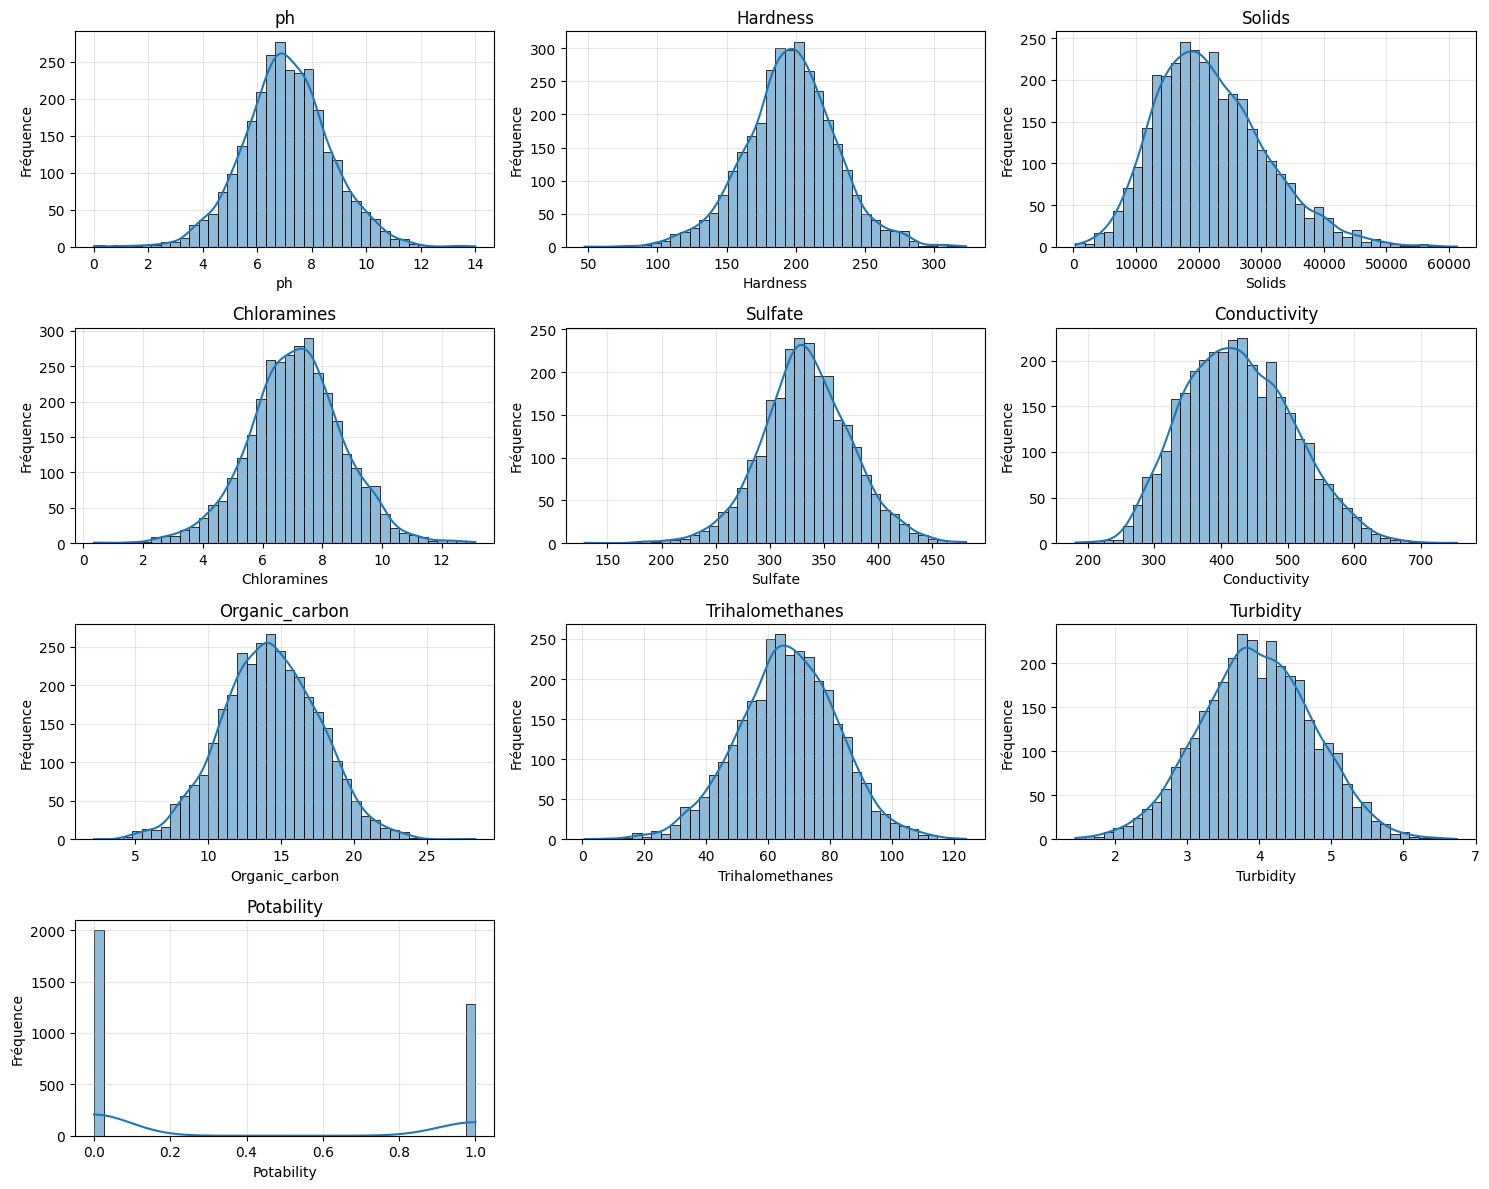

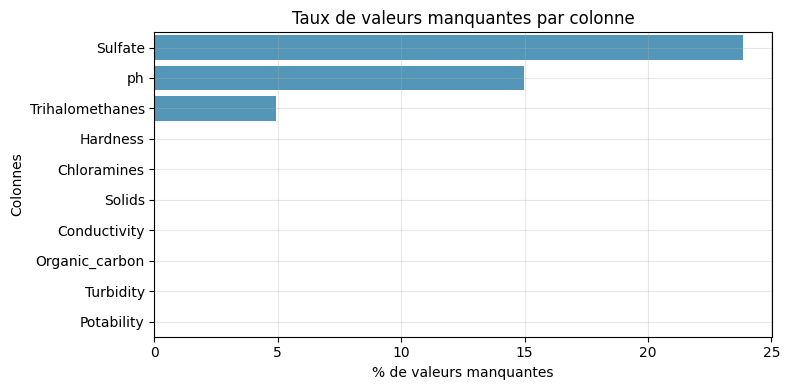

In [23]:
# 1. Chargement et Exploration Initiale (EDA)
missing_info = get_missing_summary(df)
special_cols = get_special_columns(df)

# Visualisations rapides
plot_numeric_histograms(df)
plot_missing_bar(df)

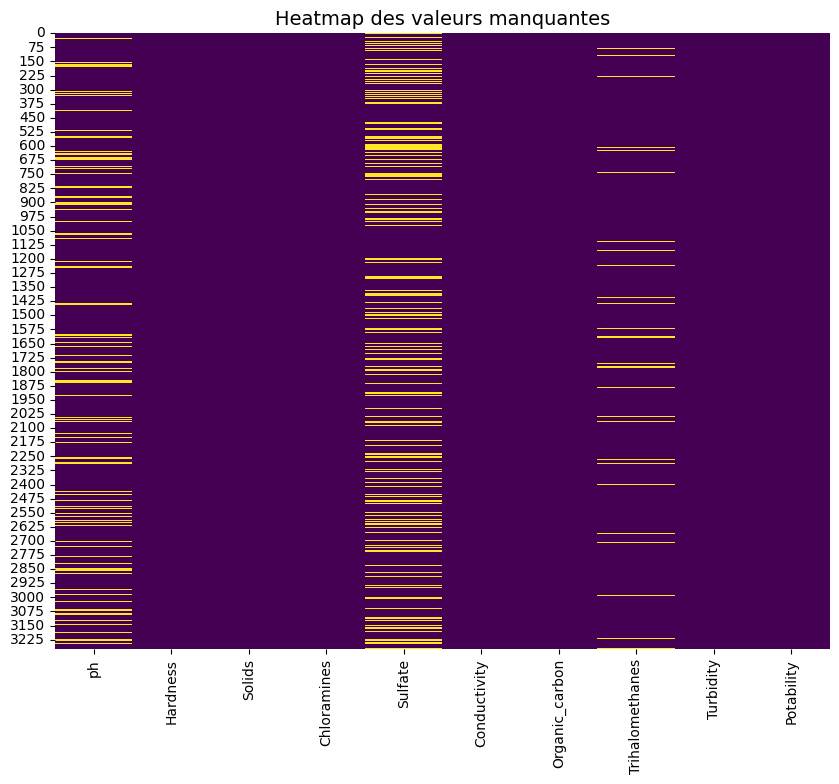

In [24]:
# Heatmap des valeurs manquantes
plt.figure(figsize=(10, 8))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Heatmap des valeurs manquantes", fontsize=14)
plt.show()


/tmp/ipykernel_33320/3856722774.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_values.index, y=missing_values.values, palette="viridis")


([0, 1, 2],
 [Text(0, 0, 'ph'), Text(1, 0, 'Sulfate'), Text(2, 0, 'Trihalomethanes')])

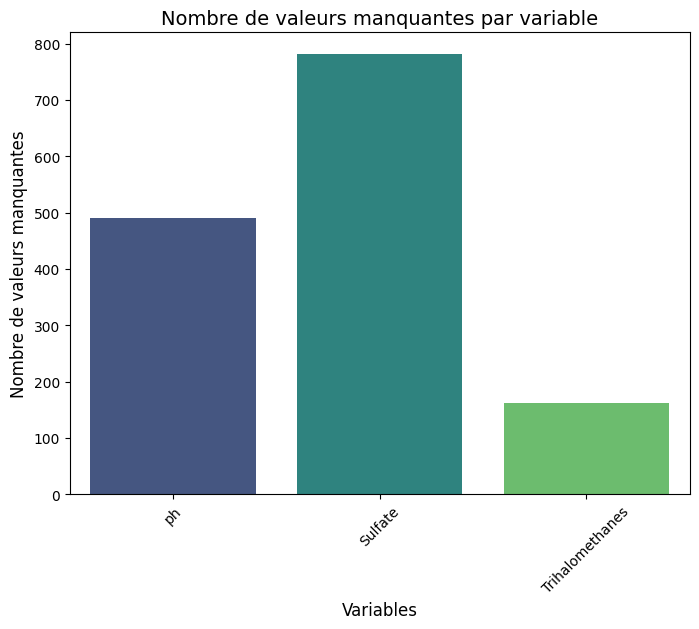

In [25]:
# Visualisation des valeurs manquantes pour les trois variables
# Calcul des valeurs manquantes
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]

# Barplot des valeurs manquantes
plt.figure(figsize=(8, 6))
sns.barplot(x=missing_values.index, y=missing_values.values, palette="viridis")
plt.title("Nombre de valeurs manquantes par variable", fontsize=14)
plt.xlabel("Variables", fontsize=12)
plt.ylabel("Nombre de valeurs manquantes", fontsize=12)
plt.xticks(rotation=45)

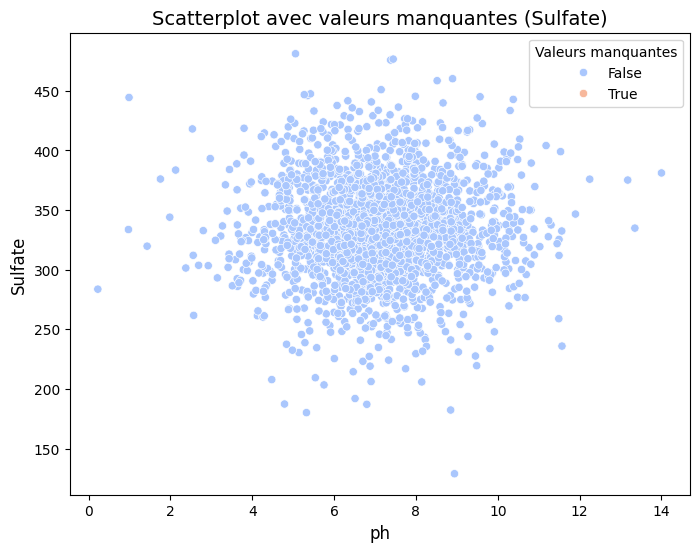

In [26]:
# Scatterplot avec indicateurs de valeurs manquantes
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="ph", y="Sulfate", hue=df["Sulfate"].isnull(), palette="coolwarm")
plt.title("Scatterplot avec valeurs manquantes (Sulfate)", fontsize=14)
plt.xlabel("ph", fontsize=12)
plt.ylabel("Sulfate", fontsize=12)
plt.legend(title="Valeurs manquantes")


/tmp/ipykernel_33320/2389532232.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=df["Sulfate"].isnull(), y="Conductivity", palette="Set2")


Text(0, 0.5, 'Conductivity')

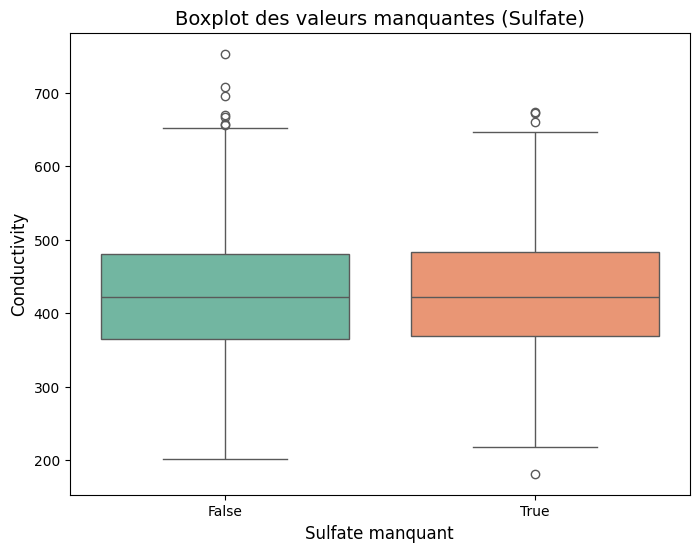

In [27]:
# Boxplot des valeurs manquantes
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x=df["Sulfate"].isnull(), y="Conductivity", palette="Set2")
plt.title("Boxplot des valeurs manquantes (Sulfate)", fontsize=14)
plt.xlabel("Sulfate manquant", fontsize=12)
plt.ylabel("Conductivity", fontsize=12)

([<matplotlib.axis.XTick at 0x73146f8c6b10>,
 [Text(0, 0, '0'), Text(1, 0, '1'), Text(2, 0, '2'), Text(3, 0, '3')])

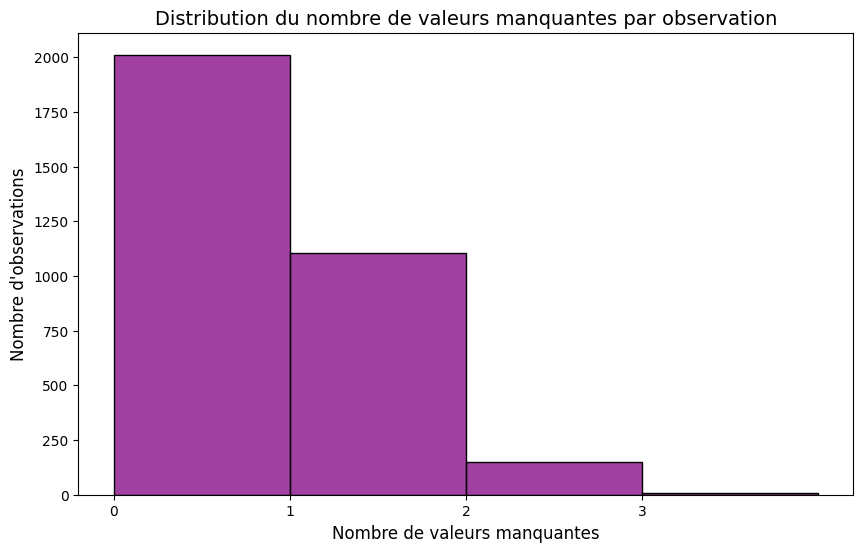

In [28]:
# Analyse des observations avec plusieurs valeurs manquantes
plt.figure(figsize=(10, 6))
df['missing_count'] = df.isnull().sum(axis=1)
sns.histplot(df['missing_count'], bins=range(0, df['missing_count'].max() + 2), kde=False, color="purple")
plt.title("Distribution du nombre de valeurs manquantes par observation", fontsize=14)
plt.xlabel("Nombre de valeurs manquantes", fontsize=12)
plt.ylabel("Nombre d'observations", fontsize=12)
plt.xticks(range(0, df['missing_count'].max() + 1))


In [29]:

# Suppression de la colonne temporaire
df.drop(columns=['missing_count'], inplace=True)

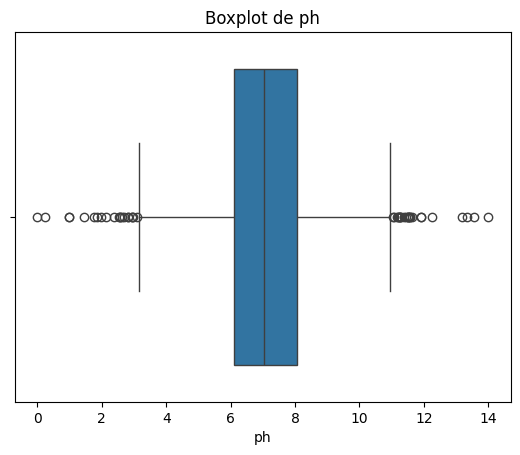

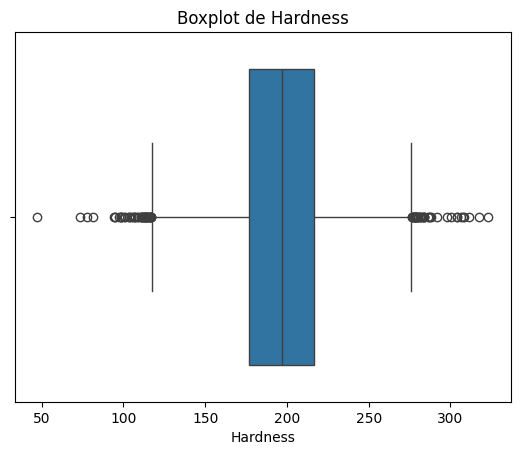

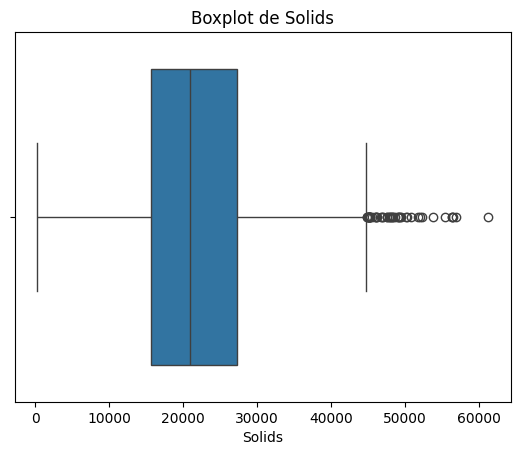

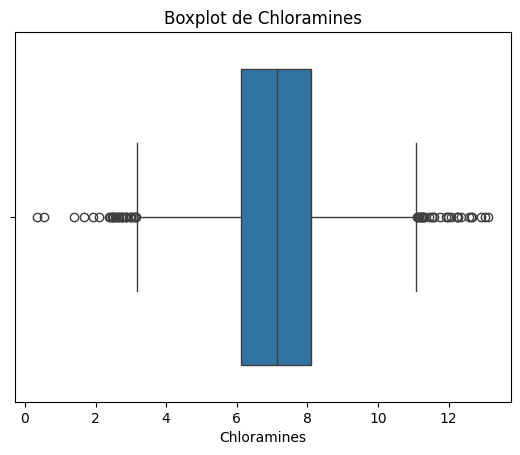

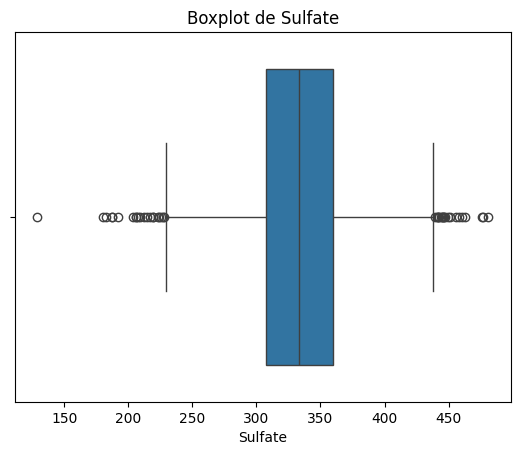

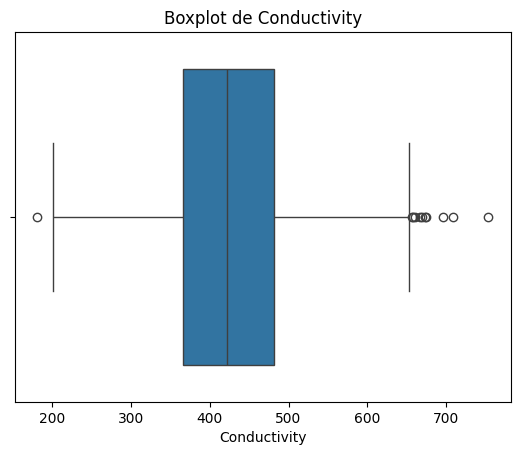

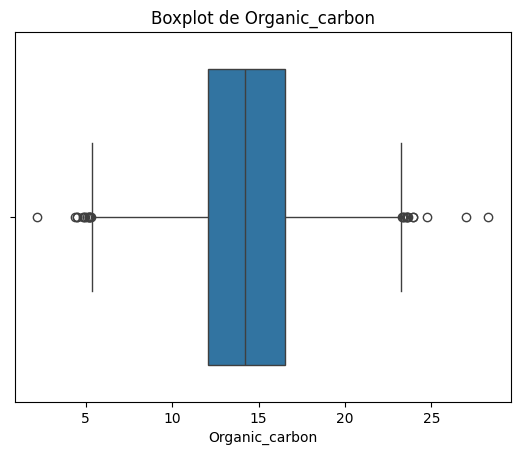

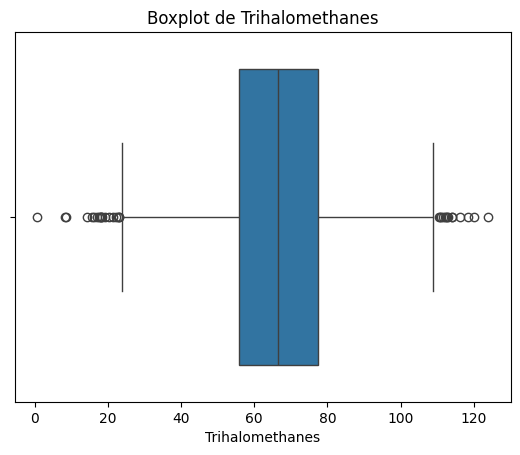

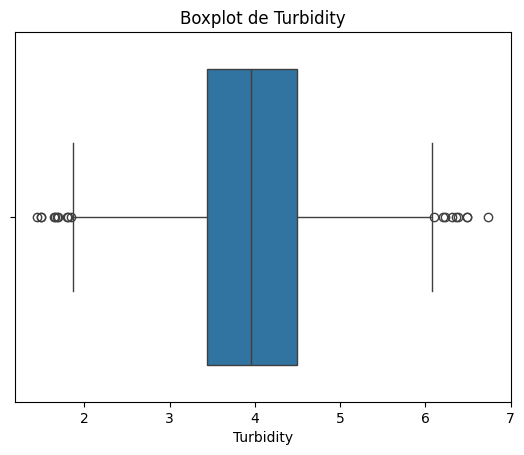

In [30]:
for col in FEATURES:
    boxplot = sns.boxplot(x=df[col])
    plt.title(f"Boxplot de {col}")
    plt.show()

Text(0.5, 1.0, 'Matrice de corrélation des features')

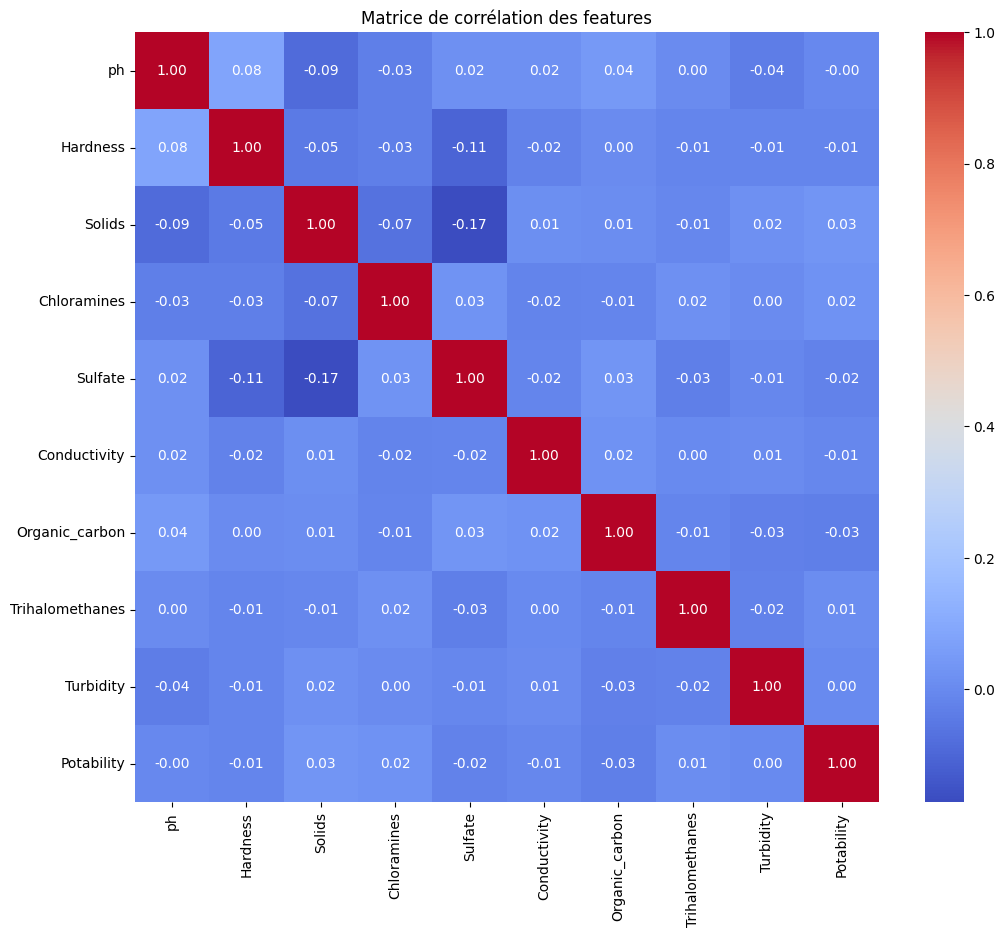

In [31]:
# Étude des corrélations entre les features
corr_matrix = df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matrice de corrélation des features")

Corrélations avec la target :
Solids             0.033743
Chloramines        0.023779
Trihalomethanes    0.007130
Turbidity          0.001581
ph                -0.003556
Conductivity      -0.008128
Hardness          -0.013837
Sulfate           -0.023577
Organic_carbon    -0.030001
dtype: float64


/tmp/ipykernel_33320/1968604428.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_corr.values, y=target_corr.index, palette="viridis")


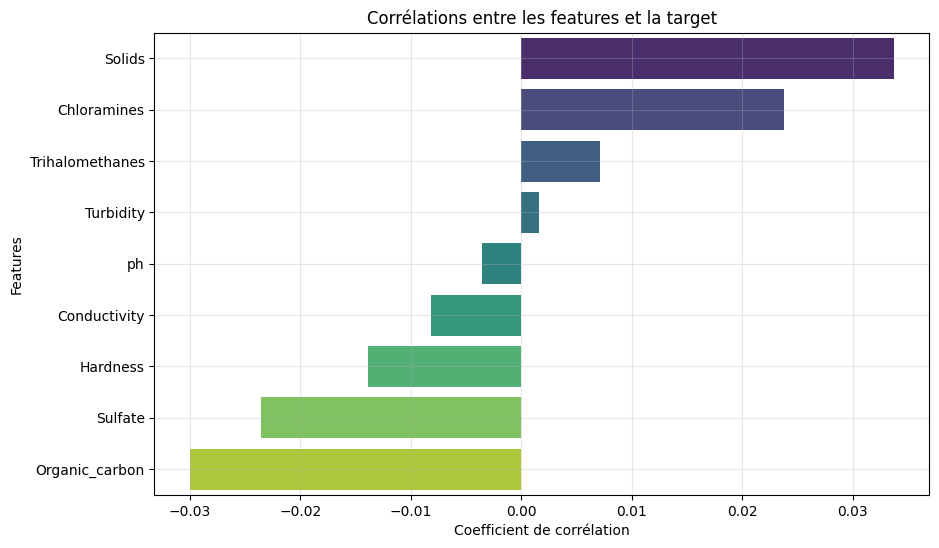

In [32]:
# Étude des corrélations entre les features et la target
target_corr = df[FEATURES].corrwith(TARGET).sort_values(ascending=False)
print("Corrélations avec la target :")
print(target_corr)

# Ajout d'un graphique pour visualiser les corrélations
plt.figure(figsize=(10, 6))
sns.barplot(x=target_corr.values, y=target_corr.index, palette="viridis")
plt.title("Corrélations entre les features et la target")
plt.xlabel("Coefficient de corrélation")
plt.ylabel("Features")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Initialise l'imputer
imputer = SimpleImputer(missing_values=np.nan, strategy='median')

# 2. applique sur les FEATURES (on exclut la target qui n'a pas de NaN)
# .fit_transform() calcule la mediane ET remplace les NaN d'un seul coup
df[FEATURES] = imputer.fit_transform(df[FEATURES])

print("Nombre de NaN restants :", df.isnull().sum().sum())

Nombre de NaN restants : 0


In [14]:
# Racine du projet
ROOT = Path.cwd().parent.resolve()

# Chemin de sauvegarde
EXPORT_PATH = ROOT / "data" / "processed" / "water_inputed.csv"

# Création du dossier si inexistant
EXPORT_PATH.parent.mkdir(parents=True, exist_ok=True)

# Export du dataframe déjà modifié
df.to_csv(EXPORT_PATH, index=False)

print(f"CSV exporté vers : {EXPORT_PATH}")

CSV exporté vers : C:\Users\ayoub\Documents\waterflow\data\processed\water_inputed.csv
